In [2]:
import pandas as pd

TIMEOUT_VAL = 300
THRESHOLD = 299.9

df = pd.read_csv('results.csv')

solvers = {
    'Proposed SAT': ('SAT', 'SAT TIME (s)'),
    'Basic SAT':    ('BSAT', 'BSAT TIME (s)'),
    'CPLEX MP':     ('MP', 'MP TIME (s)'),
    'CPLEX CP':     ('CP', 'CP TIME (s)'),
    'Gurobi':       ('GUROBI', 'GUROBI TIME (s)'),
}

# Replace TIMEOUT string with 300, convert to numeric
for label, (val_col, time_col) in solvers.items():
    df[time_col] = df[time_col].replace('TIMEOUT', TIMEOUT_VAL)
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
    df[val_col]  = df[val_col].replace('-', None)
    df[val_col]  = pd.to_numeric(df[val_col], errors='coerce')

# Extract n from filename e.g. "10_05_005_100_25_1.GSP" -> 10
df['n'] = df['FILENAME'].str.split('_').str[0].astype(int)

ns = sorted(df['n'].unique())

# -------------------------------------------------------
# 1) Flat time lists per solver (for cactus plot)
# -------------------------------------------------------
times = {}
for label, (val_col, time_col) in solvers.items():
    times[label] = df[time_col].dropna().tolist()

# -------------------------------------------------------
# 2) Instances solved per n per solver (for bar chart)
# -------------------------------------------------------
solved = {label: [] for label in solvers}
total_instances = []

for n in ns:
    subset = df[df['n'] == n]
    total_instances.append(len(subset))
    for label, (val_col, time_col) in solvers.items():
        count = (subset[time_col] < THRESHOLD).sum()
        solved[label].append(count)

# -------------------------------------------------------
# Sanity check
# -------------------------------------------------------
print("ns:", ns)
print("total_instances:", total_instances)
for label in solvers:
    print(f"{label} solved: {solved[label]}")

ns: [10, 20, 30, 40, 50]
total_instances: [66, 72, 72, 72, 72]
Proposed SAT solved: [66, 72, 71, 61, 53]
Basic SAT solved: [66, 69, 52, 43, 34]
CPLEX MP solved: [66, 71, 50, 33, 32]
CPLEX CP solved: [66, 72, 72, 72, 72]
Gurobi solved: [66, 72, 50, 35, 33]


Done.


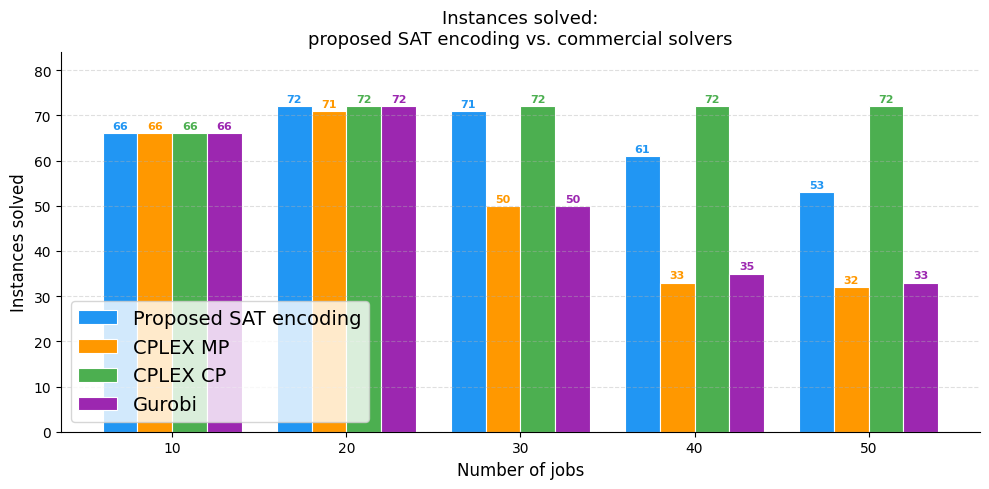

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

ns = [10, 20, 30, 40, 50]
total_instances = [66, 72, 72, 72, 72]

solved = {
    'Proposed SAT encoding': [66, 72, 71, 61, 53],
    'CPLEX MP':     [66, 71, 50, 33, 32],
    'CPLEX CP':     [66, 72, 72, 72, 72],
    'Gurobi':       [66, 72, 50, 35, 33],
}

colors = {
    'Proposed SAT encoding': '#2196F3',
    'CPLEX MP':     '#FF9800',
    'CPLEX CP':     '#4CAF50',
    'Gurobi':       '#9C27B0',
}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ns))
n_bars = len(solved)
bar_width = 0.2

for idx, (label, counts) in enumerate(solved.items()):
    counts = np.array(counts)
    offset = (idx - n_bars / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, counts, bar_width,
                  label=label,
                  color=colors[label],
                  edgecolor='white',
                  linewidth=0.8)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(val), ha='center', va='bottom',
                fontsize=8, fontweight='bold',
                color=colors[label])

ax.set_xlabel('Number of jobs', fontsize=12)
ax.set_ylabel('Instances solved', fontsize=12)
ax.set_title('Instances solved:\nproposed SAT encoding vs. commercial solvers', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in ns])
ax.set_ylim(0, max(total_instances) + 12)
ax.legend(fontsize=14, loc='lower left')
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('commercial_instances_solved.png', dpi=300, bbox_inches='tight')
plt.savefig('commercial_instances_solved.pdf', dpi=300, bbox_inches='tight')
print("Done.")

Done.


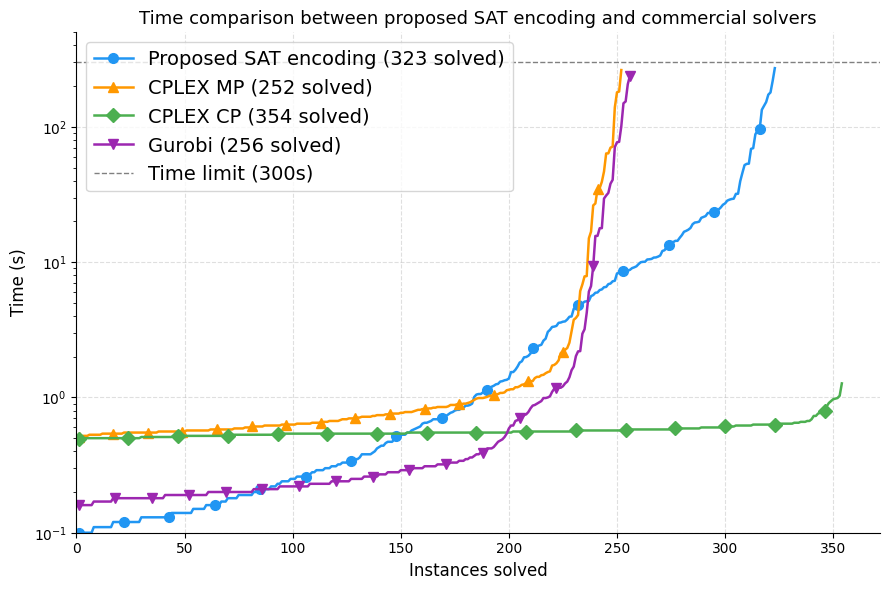

In [9]:
import matplotlib.pyplot as plt
import numpy as np

THRESHOLD = 299.9

# Fill in your flat time lists here
times = {
    'Proposed SAT encoding': df['SAT TIME (s)'],
    'CPLEX MP':     df['MP TIME (s)'],
    'CPLEX CP':     df['CP TIME (s)'],
    'Gurobi':       df['GUROBI TIME (s)'],
}

colors = {
    'Proposed SAT encoding': '#2196F3',
    'CPLEX MP':     '#FF9800',
    'CPLEX CP':     '#4CAF50',
    'Gurobi':       '#9C27B0',
}

markers = {
    'Proposed SAT encoding': 'o',
    'CPLEX MP':     '^',
    'CPLEX CP':     'D',
    'Gurobi':       'v',
}

fig, ax = plt.subplots(figsize=(9, 6))

for label, t_list in times.items():
    solved_times = sorted(t for t in t_list if t < THRESHOLD)
    if not solved_times:
        continue
    ax.plot(range(1, len(solved_times) + 1), solved_times,
            label=f'{label} ({len(solved_times)} solved)',
            color=colors[label],
            marker=markers[label],
            markevery=max(1, len(solved_times) // 15),
            markersize=7,
            linewidth=1.8)

ax.set_xlabel('Instances solved', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Time comparison between proposed SAT encoding and commercial solvers', fontsize=13)
ax.set_xlim(left=0)
ax.set_ylim(0.1, 500)  # log scale needs positive lower bound
ax.set_yscale('log')
ax.axhline(y=300, color='gray', linestyle='--',
           linewidth=1, label='Time limit (300s)')
ax.legend(fontsize=14, loc='upper left')
ax.grid(linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('commercial_cactus.png', dpi=300, bbox_inches='tight')
plt.savefig('commercial_cactus.pdf', dpi=300, bbox_inches='tight')
print("Done.")

Done.


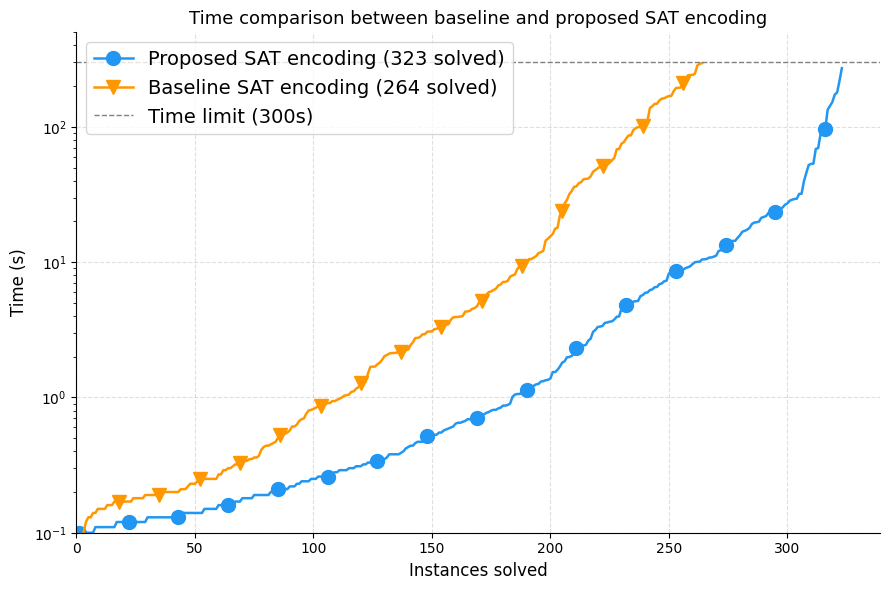

In [6]:
import matplotlib.pyplot as plt
import numpy as np

THRESHOLD = 299.9

# Fill in your flat time lists here
times = {
    'Proposed SAT encoding': df['SAT TIME (s)'],
    'Baseline SAT encoding': df['BSAT TIME (s)'],
}

colors = {
    'Proposed SAT encoding': '#2196F3',
    'Baseline SAT encoding':     '#FF9800',
}

markers = {
    'Proposed SAT encoding': 'o',
    'Baseline SAT encoding': 'v',
}

fig, ax = plt.subplots(figsize=(9, 6))

for label, t_list in times.items():
    solved_times = sorted(t for t in t_list if t < THRESHOLD)
    if not solved_times:
        continue
    ax.plot(range(1, len(solved_times) + 1), solved_times,
            label=f'{label} ({len(solved_times)} solved)',
            color=colors[label],
            marker=markers[label],
            markevery=max(1, len(solved_times) // 15),
            markersize=10,
            linewidth=1.8)

ax.set_xlabel('Instances solved', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Time comparison between baseline and proposed SAT encoding', fontsize=13)
ax.set_xlim(left=0)
ax.set_ylim(0.1, 500)  # log scale needs positive lower bound
ax.set_yscale('log')
ax.axhline(y=300, color='gray', linestyle='--',
           linewidth=1, label='Time limit (300s)')
ax.legend(fontsize=14, loc='upper left')
ax.grid(linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('commercial_cactus.png', dpi=300, bbox_inches='tight')
plt.savefig('commercial_cactus.pdf', dpi=300, bbox_inches='tight')
print("Done.")

Done.


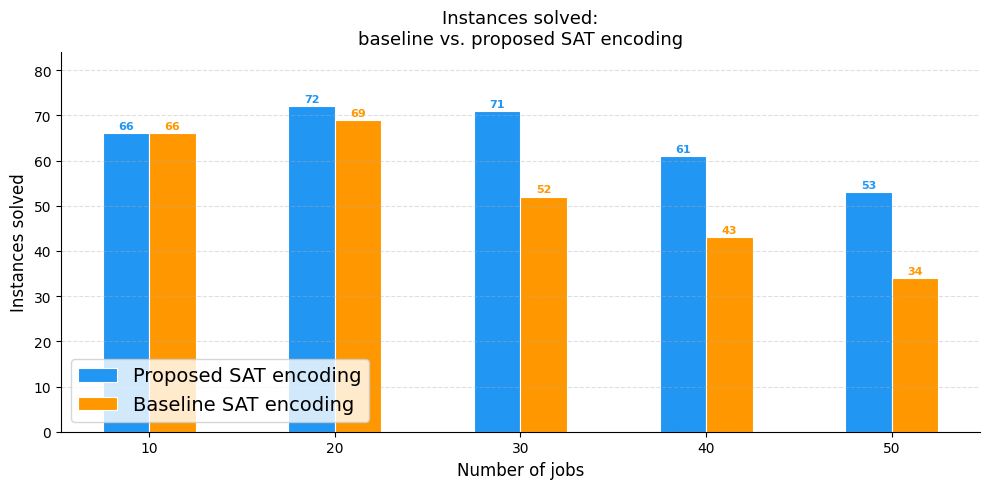

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

ns = [10, 20, 30, 40, 50]
total_instances = [66, 72, 72, 72, 72]

solved = {
    'Proposed SAT encoding': [66, 72, 71, 61, 53],
    'Baseline SAT encoding': [66, 69, 52, 43, 34]
}

colors = {
    'Proposed SAT encoding': '#2196F3',
    'Baseline SAT encoding':     '#FF9800',
}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ns))
n_bars = len(solved)
bar_width = 0.25

for idx, (label, counts) in enumerate(solved.items()):
    counts = np.array(counts)
    offset = (idx - n_bars / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, counts, bar_width,
                  label=label,
                  color=colors[label],
                  edgecolor='white',
                  linewidth=0.8)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(val), ha='center', va='bottom',
                fontsize=8, fontweight='bold',
                color=colors[label])

# Variable total instances line
# for i in range(len(ns)):
#     left  = x[i] - n_bars * bar_width / 2
#     right = x[i] + n_bars * bar_width / 2
#     ax.plot([left, right],
#             [total_instances[i], total_instances[i]],
#             color='gray', linestyle='--', linewidth=1.2,
#             label='Total instances' if i == 0 else '')

ax.set_xlabel('Number of jobs', fontsize=12)
ax.set_ylabel('Instances solved', fontsize=12)
ax.set_title('Instances solved:\nbaseline vs. proposed SAT encoding', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in ns])
ax.set_ylim(0, max(total_instances) + 12)
ax.legend(fontsize=14, loc='lower left')
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('commercial_instances_solved.png', dpi=300, bbox_inches='tight')
plt.savefig('commercial_instances_solved.pdf', dpi=300, bbox_inches='tight')
print("Done.")

Both found bound: 24
Proposed SAT encoding only: 7
Done.


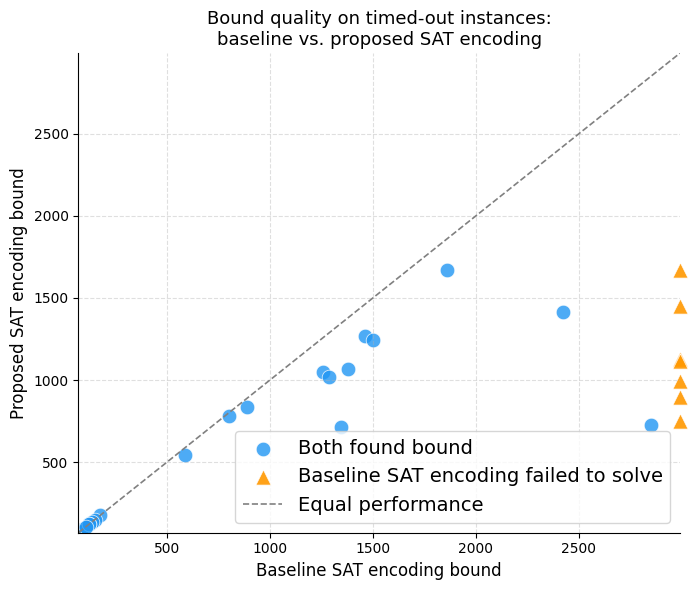

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Both timed out
mask_both_timeout = (
    (df['SAT TIME (s)'] >= 300) &
    (df['BSAT TIME (s)'] >= 300)
)
df_both = df[mask_both_timeout]

# Split into two groups
df_both_found = df_both[df_both['SAT'].notna() & df_both['BSAT'].notna()]
df_sat_only   = df_both[df_both['SAT'].notna() & df_both['BSAT'].isna()]

sat_bounds      = df_both_found['SAT'].astype(float).values
bsat_bounds     = df_both_found['BSAT'].astype(float).values
sat_only_bounds = df_sat_only['SAT'].astype(float).values

print(f"Both found bound: {len(df_both_found)}")
print(f"Proposed SAT encoding only: {len(df_sat_only)}")

fig, ax = plt.subplots(figsize=(7, 6))

# Axis limits from all real bound values
all_vals = np.concatenate([sat_bounds, bsat_bounds, sat_only_bounds])
lim_min = all_vals.min() * 0.95
lim_max = all_vals.max() * 1.05

# Fixed x position for BSAT-failed points — far right
phantom_x = lim_max

# --- Points where both found a bound ---
ax.scatter(bsat_bounds, sat_bounds,
           color='#2196F3', edgecolors='white',
           marker='o', linewidth=0.6, s=110, alpha=0.8,
           label='Both found bound')

# --- Points where BSAT failed — pushed to far right ---
ax.scatter([phantom_x] * len(sat_only_bounds), sat_only_bounds,
           color="#FF9800", edgecolors='white',
           marker='^', linewidth=0.6, s=120, alpha=0.9,
           label='Baseline SAT encoding failed to solve',
           clip_on=False)

# --- Diagonal reference line ---
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color='gray', linestyle='--', linewidth=1.2,
        label='Equal performance')

ax.set_xlabel('Baseline SAT encoding bound', fontsize=12)
ax.set_ylabel('Proposed SAT encoding bound', fontsize=12)
ax.set_title('Bound quality on timed-out instances:\nbaseline vs. proposed SAT encoding', fontsize=13)
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.legend(fontsize=14, loc='lower right')
ax.grid(linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotation
below = (sat_bounds < bsat_bounds).sum()
equal = (sat_bounds == bsat_bounds).sum()
above = (sat_bounds > bsat_bounds).sum()

plt.tight_layout()
plt.savefig('sat_bound_scatter.png', dpi=300, bbox_inches='tight')
plt.savefig('sat_bound_scatter.pdf', dpi=300, bbox_inches='tight')
print("Done.")

In [2]:
import pandas as pd

df = pd.read_csv('results.csv')

def format_time(time_val):
    if str(time_val).strip().upper() == 'TIMEOUT':
        return 'timeout'
    try:
        t = float(time_val)
        if t >= 300:
            return 'timeout'
        return f'{t:.2f}'
    except:
        return str(time_val)

def format_bound(bound_val):
    if pd.isna(bound_val) or str(bound_val).strip() == '-':
        return '-'
    try:
        return str(int(float(bound_val)))
    except:
        return str(bound_val)

def get_instance_name(filename):
    # Remove .GSP extension
    return filename.replace('.GSP', '').replace('_', '\\_')

lines = []
prev_n = None

for _, row in df.iterrows():
    filename = str(row['FILENAME'])
    n = int(filename.split('_')[0])

    # Add midrule between different n groups
    if prev_n is not None and n != prev_n:
        lines.append('\\midrule')
    prev_n = n

    instance = get_instance_name(filename)
    pt       = str(row['TYPE'])

    bsat_time  = format_time(row['BSAT TIME (s)'])
    bsat_bound = format_bound(row['BSAT'])

    sat_time   = format_time(row['SAT TIME (s)'])
    sat_bound  = format_bound(row['SAT'])

    cp_time    = format_time(row['CP TIME (s)'])
    cp_bound   = format_bound(row['CP'])

    mp_time    = format_time(row['MP TIME (s)'])
    mp_bound   = format_bound(row['MP'])

    gurobi_time  = format_time(row['GUROBI TIME (s)'])
    gurobi_bound = format_bound(row['GUROBI'])

    line = (
        f'{instance} & {pt} & '
        f'{bsat_time} & {bsat_bound} & '
        f'{sat_time} & {sat_bound} & '
        f'{cp_time} & {cp_bound} & '
        f'{mp_time} & {mp_bound} & '
        f'{gurobi_time} & {gurobi_bound} \\\\'
    )
    lines.append(line)

# Write to file
with open('appendix_rows.tex', 'w') as f:
    for line in lines:
        f.write(line + '\n')

print(f"Generated {len(lines)} lines.")

Generated 358 lines.
